# Step 4.2 — Bioactivity Prediction

**Purpose:** Screen the proteolytic fragments from Step 4.1 for predicted bioactivity,
focusing on antioxidant potential. Compare predicted bioactive peptide yield under
DES vs water digestion conditions to connect the MD findings (Phase 3) and
proteolysis predictions (Step 4.1) to the Durrani et al. experimental observations.

**Inputs:**
- `downstream/proteolysis/bioactivity_candidates.csv` — 9 unique candidate sequences from Step 4.1
- `downstream/proteolysis/cleavage_fragments.csv` — all 26 fragments with motif annotations
- Phase 3 SASA summary data (hardcoded from README)
- Durrani et al. experimental antioxidant data (DPPH, ABTS, FRAP)

**Outputs:**
- `downstream/bioactivity/physicochemical_profiles.csv` — MW, pI, hydrophobicity, charge, composition
- `downstream/bioactivity/antioxidant_features.csv` — antioxidant-relevant residue analysis
- `downstream/bioactivity/bioactivity_summary.csv` — integrated scores per fragment
- `downstream/bioactivity/web_tool_input.txt` — formatted sequences for PeptideRanker / AntiCP submission
- `downstream/bioactivity/figures/` — bioactivity visualisations

**Analysis components:**
1. **Local (computed here):**
   - Physicochemical profiling (MW, pI, net charge, GRAVY, instability index)
   - Antioxidant-relevant amino acid composition (C, M, W, Y, H — known radical scavengers)
   - Structural antioxidant feature scoring based on Durrani et al. Fig. 6 SAR analysis
   - BIOPEP-UWM motif matching for known bioactive sequences

2. **External (formatted for web submission):**
   - PeptideRanker input (FASTA format)
   - AntiCP 2.0 input (FASTA format)

**Runtime estimate:** < 30 seconds

## 1. Imports and configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# --- Directories ---
PROT_DIR = Path('downstream/proteolysis')
OUT_DIR = Path('downstream/bioactivity')
FIG_DIR = OUT_DIR / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- Load Step 4.1 outputs ---
df_candidates = pd.read_csv(PROT_DIR / 'bioactivity_candidates.csv')
df_fragments = pd.read_csv(PROT_DIR / 'cleavage_fragments.csv')

print(f"Loaded {len(df_candidates)} bioactivity candidates from Step 4.1")
print(f"Loaded {len(df_fragments)} total fragments from Step 4.1")
print(f"\nCandidate sequences:")
for _, row in df_candidates.iterrows():
    print(f"  {row['fragment_sequence']:25s} ({row['fragment_length']} aa) "
          f"— {row['peptide']}, {row['protease']}")

Loaded 9 bioactivity candidates from Step 4.1
Loaded 26 total fragments from Step 4.1

Candidate sequences:
  NTDEEEGGEIVFGGVDPK        (18 aa) — GGE, Trypsin
  NTDEEEGGEIVF              (12 aa) — GGE, Chymotrypsin
  NTDEEEGGEIV               (11 aa) — GGE, Pepsin (pH 2)
  LYQCMEFVR                 (9 aa) — CME, Trypsin
  QCME                      (4 aa) — CME, Pepsin (pH 2)
  NPYIYK                    (6 aa) — YIY, Trypsin
  GGE                       (3 aa) — GGE, Motif only (reference)
  CME                       (3 aa) — CME, Motif only (reference)
  YIY                       (3 aa) — YIY, Motif only (reference)


## 2. Amino acid property tables

Standard physicochemical scales used for peptide characterisation.

In [2]:
# Monoisotopic residue masses (Da) — standard 20 amino acids
AA_MASS = {
    'A': 71.03711, 'R': 156.10111, 'N': 114.04293, 'D': 115.02694, 'C': 103.00919,
    'E': 129.04259, 'Q': 128.05858, 'G': 57.02146, 'H': 137.05891, 'I': 113.08406,
    'L': 113.08406, 'K': 128.09496, 'M': 131.04049, 'F': 147.06841, 'P': 97.05276,
    'S': 87.03203, 'T': 101.04768, 'W': 186.07931, 'Y': 163.06333, 'V': 99.06841,
}
WATER_MASS = 18.01056  # added once for intact peptide

# Kyte-Doolittle hydrophobicity scale
KD_HYDRO = {
    'A': 1.8, 'R': -4.5, 'N': -3.5, 'D': -3.5, 'C': 2.5,
    'E': -3.5, 'Q': -3.5, 'G': -0.4, 'H': -3.2, 'I': 4.5,
    'L': 3.8, 'K': -3.9, 'M': 1.9, 'F': 2.8, 'P': -1.6,
    'S': -0.8, 'T': -0.7, 'W': -0.9, 'Y': -1.3, 'V': 4.2,
}

# pKa values for pI calculation
# N-terminus, C-terminus, and ionisable side chains
PKA_NTERM = 9.69
PKA_CTERM = 2.34
PKA_SIDECHAIN = {
    'D': 3.65, 'E': 4.25, 'H': 6.00, 'C': 8.18,
    'Y': 10.07, 'K': 10.53, 'R': 12.48,
}

# Antioxidant-relevant residue classification
# Based on established SAR and Durrani et al. Fig. 6 analysis
ANTIOXIDANT_RESIDUES = {
    # Strong radical scavengers
    'C': {'role': 'thiol radical scavenger', 'weight': 3.0,
          'mechanism': 'Thiol group donates H-atom to neutralise radicals'},
    'M': {'role': 'thioether radical scavenger', 'weight': 2.5,
          'mechanism': 'Thioether group has strong reducing properties'},
    'W': {'role': 'indole radical scavenger', 'weight': 2.5,
          'mechanism': 'Indole ring stabilises radical intermediates'},
    'Y': {'role': 'phenolic H-donor', 'weight': 2.5,
          'mechanism': 'Phenolic -OH donates H-atom; conjugated ring stabilises radical'},
    'H': {'role': 'metal chelator / radical trap', 'weight': 2.0,
          'mechanism': 'Imidazole ring chelates transition metals and traps radicals'},
    # Moderate contributors
    'F': {'role': 'hydrophobic / pi-stacking', 'weight': 1.0,
          'mechanism': 'Aromatic ring provides hydrophobic shielding'},
    'P': {'role': 'structural constraint', 'weight': 0.5,
          'mechanism': 'Constrains backbone, may enhance active conformation'},
    'E': {'role': 'metal chelator (weak)', 'weight': 1.5,
          'mechanism': 'Carboxyl group can chelate transition metal ions (Fe²⁺, Cu²⁺)'},
    'D': {'role': 'metal chelator (weak)', 'weight': 1.5,
          'mechanism': 'Carboxyl group can chelate transition metal ions'},
}

print("Property tables loaded.")
print(f"Antioxidant-relevant residues: {', '.join(sorted(ANTIOXIDANT_RESIDUES.keys()))}")

Property tables loaded.
Antioxidant-relevant residues: C, D, E, F, H, M, P, W, Y


## 3. Physicochemical profiling functions

In [3]:
def calc_molecular_weight(sequence):
    """Calculate monoisotopic molecular weight of a peptide (Da)."""
    return sum(AA_MASS.get(aa, 0) for aa in sequence) + WATER_MASS


def calc_gravy(sequence):
    """Calculate Grand Average of Hydropathicity (GRAVY)."""
    if len(sequence) == 0:
        return 0.0
    return sum(KD_HYDRO.get(aa, 0) for aa in sequence) / len(sequence)


def calc_net_charge(sequence, pH=7.0):
    """Estimate net charge at a given pH using Henderson-Hasselbalch."""
    # Positive charges: N-term, K, R, H
    charge = 1.0 / (1.0 + 10**(pH - PKA_NTERM))  # N-terminus
    for aa in sequence:
        if aa in ('K', 'R', 'H'):
            pka = PKA_SIDECHAIN[aa]
            charge += 1.0 / (1.0 + 10**(pH - pka))
    
    # Negative charges: C-term, D, E, C, Y
    charge -= 1.0 / (1.0 + 10**(PKA_CTERM - pH))  # C-terminus
    for aa in sequence:
        if aa in ('D', 'E', 'C', 'Y'):
            pka = PKA_SIDECHAIN[aa]
            charge -= 1.0 / (1.0 + 10**(pka - pH))
    
    return charge


def calc_pI(sequence, precision=0.01):
    """Estimate isoelectric point by bisection."""
    pH_lo, pH_hi = 0.0, 14.0
    while (pH_hi - pH_lo) > precision:
        pH_mid = (pH_lo + pH_hi) / 2.0
        charge = calc_net_charge(sequence, pH_mid)
        if charge > 0:
            pH_lo = pH_mid
        else:
            pH_hi = pH_mid
    return (pH_lo + pH_hi) / 2.0


def calc_instability_index(sequence):
    """Calculate instability index (Guruprasad et al., 1990).
    
    Values > 40 indicate the protein is unstable.
    Uses DIWV dipeptide weight values.
    """
    # Simplified DIWV table — common dipeptide instability weights
    # Full 400-entry table is standard but we use a representative subset
    # For short peptides (<10 aa), this is an approximation
    DIWV = {
        'WW': 1.0, 'WC': 1.0, 'WM': 24.68, 'CK': 1.0, 'CC': 1.0,
        'EE': 26.81, 'GG': 13.34, 'EG': 14.39, 'GE': -7.49,
        'IV': -7.49, 'VF': 1.0, 'FG': 1.0, 'GV': -7.49, 'VD': 1.0,
        'DP': 1.0, 'PK': -6.54, 'YI': 1.0, 'IY': 1.0, 'YK': 1.0,
        'NP': -1.88, 'QC': -6.54, 'CM': 33.6, 'ME': 1.0, 'EF': 1.0,
        'FV': 1.0, 'VR': 1.0, 'LY': -7.49, 'YQ': -6.54,
    }
    if len(sequence) < 2:
        return 0.0
    total = 0.0
    for i in range(len(sequence) - 1):
        dipeptide = sequence[i:i+2]
        total += DIWV.get(dipeptide, 1.0)  # default weight 1.0
    return (10.0 / len(sequence)) * total


def amino_acid_composition(sequence):
    """Return dict of amino acid fractional composition."""
    comp = {}
    n = len(sequence)
    if n == 0:
        return comp
    for aa in set(sequence):
        comp[aa] = sequence.count(aa) / n
    return comp


print("Physicochemical functions defined.")

Physicochemical functions defined.


## 4. Antioxidant feature scoring

Score each peptide for antioxidant potential based on:
1. Presence and count of antioxidant-relevant residues (C, M, W, Y, H, E, D)
2. Fractional antioxidant residue content
3. Weighted antioxidant score based on residue-specific mechanisms
4. Consistency with Durrani et al. structure-activity relationships (Fig. 6)

In [4]:
def antioxidant_score(sequence):
    """Compute a weighted antioxidant feature score for a peptide.
    
    Returns
    -------
    dict with:
        'raw_score': sum of antioxidant residue weights
        'normalised_score': raw_score / peptide_length (density)
        'antioxidant_residue_count': number of antioxidant residues
        'antioxidant_fraction': fraction of residues that are antioxidant-relevant
        'residue_contributions': list of (residue, position, weight, mechanism)
    """
    contributions = []
    raw = 0.0
    count = 0
    
    for i, aa in enumerate(sequence):
        if aa in ANTIOXIDANT_RESIDUES:
            info = ANTIOXIDANT_RESIDUES[aa]
            raw += info['weight']
            count += 1
            contributions.append((aa, i, info['weight'], info['role']))
    
    n = len(sequence)
    return {
        'raw_score': raw,
        'normalised_score': raw / n if n > 0 else 0,
        'antioxidant_residue_count': count,
        'antioxidant_fraction': count / n if n > 0 else 0,
        'residue_contributions': contributions,
    }


def known_bioactive_motifs(sequence):
    """Screen for known bioactive peptide motifs from BIOPEP-UWM database.
    
    This is a curated subset of established short bioactive motifs relevant
    to antioxidant, ACE-inhibitory, and DPP-IV inhibitory activities.
    Not exhaustive — supplement with actual BIOPEP-UWM web search.
    """
    # Curated motifs: (pattern, activity, reference)
    MOTIFS = [
        # Antioxidant motifs
        ('EE', 'antioxidant', 'Glu-Glu metal chelation'),
        ('GGE', 'antioxidant', 'Durrani et al. — T. grandis antioxidant'),
        ('CME', 'antioxidant', 'Durrani et al. — T. grandis antioxidant (highest activity)'),
        ('YIY', 'antioxidant', 'Durrani et al. — T. grandis antioxidant'),
        ('VY', 'antioxidant', 'Val-Tyr radical scavenging'),
        ('EY', 'antioxidant', 'Glu-Tyr radical scavenging'),
        # ACE-inhibitory motifs
        ('VF', 'ACE-inhibitory', 'Val-Phe C-domain binding'),
        ('GG', 'ACE-inhibitory', 'Gly-Gly backbone flexibility'),
        ('IVF', 'ACE-inhibitory', 'Ile-Val-Phe hydrophobic tripeptide'),
        ('VR', 'ACE-inhibitory', 'Val-Arg C-terminal'),
        ('PK', 'ACE-inhibitory', 'Pro-Lys'),
        # DPP-IV inhibitory
        ('GP', 'DPP-IV inhibitory', 'Gly-Pro dipeptide'),
        ('IY', 'DPP-IV inhibitory', 'Ile-Tyr'),
    ]
    
    hits = []
    for pattern, activity, ref in MOTIFS:
        pos = 0
        while True:
            idx = sequence.find(pattern, pos)
            if idx == -1:
                break
            hits.append({
                'pattern': pattern,
                'activity': activity,
                'position': idx,
                'reference': ref,
            })
            pos = idx + 1
    return hits


print("Antioxidant scoring and motif search functions defined.")

Antioxidant scoring and motif search functions defined.


## 5. Compute profiles for all candidate sequences

In [5]:
profile_rows = []

for _, cand in df_candidates.iterrows():
    seq = cand['fragment_sequence']
    n = len(seq)
    
    # Physicochemical
    mw = calc_molecular_weight(seq)
    gravy = calc_gravy(seq)
    charge_7 = calc_net_charge(seq, 7.0)
    pI = calc_pI(seq)
    ii = calc_instability_index(seq)
    
    # Antioxidant scoring
    aox = antioxidant_score(seq)
    
    # Bioactive motif search
    motif_hits = known_bioactive_motifs(seq)
    
    # Amino acid composition
    comp = amino_acid_composition(seq)
    
    row = {
        'sequence': seq,
        'length': n,
        'peptide': cand['peptide'],
        'motif': cand['motif'],
        'protease': cand['protease'],
        'MW_Da': round(mw, 2),
        'pI': round(pI, 2),
        'charge_pH7': round(charge_7, 2),
        'GRAVY': round(gravy, 3),
        'instability_index': round(ii, 1),
        'aox_raw_score': round(aox['raw_score'], 2),
        'aox_normalised': round(aox['normalised_score'], 3),
        'aox_residue_count': aox['antioxidant_residue_count'],
        'aox_residue_fraction': round(aox['antioxidant_fraction'], 3),
        'n_bioactive_motifs': len(motif_hits),
        'bioactive_motifs': '; '.join(f"{h['pattern']}({h['activity']})" for h in motif_hits) if motif_hits else 'none',
        # Key antioxidant residue counts
        'n_Cys': seq.count('C'),
        'n_Met': seq.count('M'),
        'n_Trp': seq.count('W'),
        'n_Tyr': seq.count('Y'),
        'n_His': seq.count('H'),
        'n_Glu': seq.count('E'),
        'n_Asp': seq.count('D'),
        'n_Phe': seq.count('F'),
    }
    profile_rows.append(row)

df_profiles = pd.DataFrame(profile_rows)
df_profiles.to_csv(OUT_DIR / 'physicochemical_profiles.csv', index=False)

# Display
display_cols = ['sequence', 'length', 'MW_Da', 'pI', 'charge_pH7', 'GRAVY',
                'aox_raw_score', 'aox_normalised', 'n_bioactive_motifs']
print("Physicochemical and antioxidant profiles:")
print(df_profiles[display_cols].to_string(index=False))
print(f"\nSaved → {OUT_DIR / 'physicochemical_profiles.csv'}")

Physicochemical and antioxidant profiles:
          sequence  length   MW_Da   pI  charge_pH7  GRAVY  aox_raw_score  aox_normalised  n_bioactive_motifs
NTDEEEGGEIVFGGVDPK      18 1890.85 3.34       -4.99 -0.922           10.5           0.583                   8
      NTDEEEGGEIVF      12 1337.56 2.80       -4.99 -0.917            8.5           0.708                   6
       NTDEEEGGEIV      11 1190.49 2.80       -4.99 -1.255            7.5           0.682                   4
         LYQCMEFVR       9 1187.55 6.21       -0.06  0.267           10.5           1.167                   2
              QCME       4  509.16 3.30       -1.06 -0.650            7.0           1.750                   1
            NPYIYK       6  796.41 9.56        1.00 -1.183            5.5           0.917                   2
               GGE       3  261.10 3.30       -1.00 -1.433            1.5           0.500                   2
               CME       3  381.10 3.30       -1.06  0.300            7.0     

## 6. Detailed antioxidant feature breakdown

For each candidate, enumerate the specific residues contributing to
antioxidant potential and their mechanisms. This connects directly to
Durrani et al. Fig. 6 SAR analysis.

In [6]:
aox_detail_rows = []

print("="*70)
print("ANTIOXIDANT FEATURE ANALYSIS — PER CANDIDATE")
print("="*70)

for _, cand in df_candidates.iterrows():
    seq = cand['fragment_sequence']
    aox = antioxidant_score(seq)
    motifs = known_bioactive_motifs(seq)
    
    print(f"\n  {seq} ({cand['peptide']}, {cand['protease']})")
    print(f"  Antioxidant score: {aox['raw_score']:.1f} (raw), "
          f"{aox['normalised_score']:.3f} (per residue)")
    
    if aox['residue_contributions']:
        print(f"  Contributing residues:")
        for aa, pos, weight, role in aox['residue_contributions']:
            print(f"    {aa}{pos+1}: {role} (weight={weight})")
    else:
        print(f"  No recognised antioxidant residues.")
    
    if motifs:
        print(f"  Bioactive motifs found:")
        for m in motifs:
            print(f"    {m['pattern']} at pos {m['position']+1}: "
                  f"{m['activity']} — {m['reference']}")
    
    for aa, pos, weight, role in aox['residue_contributions']:
        mechanism = ANTIOXIDANT_RESIDUES[aa]['mechanism']
        aox_detail_rows.append({
            'sequence': seq,
            'peptide': cand['peptide'],
            'residue': aa,
            'position_1idx': pos + 1,
            'weight': weight,
            'role': role,
            'mechanism': mechanism,
        })

df_aox_detail = pd.DataFrame(aox_detail_rows)
df_aox_detail.to_csv(OUT_DIR / 'antioxidant_features.csv', index=False)
print(f"\nSaved → {OUT_DIR / 'antioxidant_features.csv'}")

ANTIOXIDANT FEATURE ANALYSIS — PER CANDIDATE

  NTDEEEGGEIVFGGVDPK (GGE, Trypsin)
  Antioxidant score: 10.5 (raw), 0.583 (per residue)
  Contributing residues:
    D3: metal chelator (weak) (weight=1.5)
    E4: metal chelator (weak) (weight=1.5)
    E5: metal chelator (weak) (weight=1.5)
    E6: metal chelator (weak) (weight=1.5)
    E9: metal chelator (weak) (weight=1.5)
    F12: hydrophobic / pi-stacking (weight=1.0)
    D16: metal chelator (weak) (weight=1.5)
    P17: structural constraint (weight=0.5)
  Bioactive motifs found:
    EE at pos 4: antioxidant — Glu-Glu metal chelation
    EE at pos 5: antioxidant — Glu-Glu metal chelation
    GGE at pos 7: antioxidant — Durrani et al. — T. grandis antioxidant
    VF at pos 11: ACE-inhibitory — Val-Phe C-domain binding
    GG at pos 7: ACE-inhibitory — Gly-Gly backbone flexibility
    GG at pos 13: ACE-inhibitory — Gly-Gly backbone flexibility
    IVF at pos 10: ACE-inhibitory — Ile-Val-Phe hydrophobic tripeptide
    PK at pos 17: ACE-i

## 7. Protease-dependent bioactive yield analysis

The central question: which protease condition produces the highest yield
of bioactive fragments, and does DES solvent exposure (enhanced motif
accessibility) predict increased yield?

We aggregate across the full fragment set from Step 4.1, not just the
intact-motif candidates.

In [7]:
# Score all 26 fragments (not just intact-motif candidates)
all_scored = []

for _, frag in df_fragments.iterrows():
    seq = frag['fragment_sequence']
    n = len(seq)
    aox = antioxidant_score(seq)
    motifs = known_bioactive_motifs(seq)
    
    all_scored.append({
        'peptide': frag['peptide'],
        'protease': frag['protease'],
        'sequence': seq,
        'length': n,
        'motif_status': frag['motif_status'],
        'aox_raw': aox['raw_score'],
        'aox_norm': aox['normalised_score'],
        'n_motifs': len(motifs),
        'has_intact_motif': frag['motif_status'] == 'intact',
    })

df_all_scored = pd.DataFrame(all_scored)

# Aggregate: per peptide × protease, sum antioxidant scores of fragments
agg = df_all_scored.groupby(['peptide', 'protease']).agg(
    n_fragments=('sequence', 'count'),
    n_intact_motif=('has_intact_motif', 'sum'),
    total_aox_score=('aox_raw', 'sum'),
    max_fragment_aox=('aox_raw', 'max'),
    total_bioactive_motifs=('n_motifs', 'sum'),
    mean_fragment_length=('length', 'mean'),
).reset_index()

print("Protease-dependent bioactive fragment yield:")
print(agg.to_string(index=False))
print(f"\n(Total antioxidant score = sum of raw aox scores across all fragments)")

Protease-dependent bioactive fragment yield:
peptide      protease  n_fragments  n_intact_motif  total_aox_score  max_fragment_aox  total_bioactive_motifs  mean_fragment_length
    CME  Chymotrypsin            5               0             10.5               5.5                       1                   1.8
    CME Pepsin (pH 2)            5               1             10.5               7.0                       2                   1.8
    CME       Trypsin            1               1             10.5              10.5                       2                   9.0
    GGE  Chymotrypsin            2               1             10.5               8.5                       8                   9.0
    GGE Pepsin (pH 2)            3               1             10.5               7.5                       6                   6.0
    GGE       Trypsin            1               1             10.5              10.5                       8                  18.0
    YIY  Chymotrypsin          

## 8. Integration with Durrani et al. experimental data

Compare our computational predictions against the experimental antioxidant
activity ranking from Durrani et al.:
- CME had the highest antioxidant activity
- GGE and YIY also showed significant activity
- DES-extracted proteins showed higher DPPH, ABTS, and FRAP than water extraction

In [8]:
# Experimental data from Durrani et al. manuscript
DURRANI_EXP = {
    'extraction_comparison': {
        'DES_ABTS': 0.751,    # μmol Trolox/mg prot
        'Water_ABTS': 0.630,
        'DES_DPPH': 0.060,
        'Water_DPPH': 0.036,
        'DES_FRAP': 5.488,
        'Water_FRAP': 5.160,
    },
    'motif_ranking': {
        'CME': 'highest activity',
        'GGE': 'significant activity',
        'YIY': 'significant activity',
    },
}

# Our computational antioxidant ranking (bare tripeptide motifs)
motif_scores = {}
for _, row in df_profiles[df_profiles['protease'] == 'Motif only (reference)'].iterrows():
    motif_scores[row['motif']] = {
        'aox_raw': row['aox_raw_score'],
        'aox_norm': row['aox_normalised'],
    }

print("="*70)
print("COMPUTATIONAL vs EXPERIMENTAL ANTIOXIDANT RANKING")
print("="*70)

print("\n  Durrani et al. experimental ranking: CME > GGE ≈ YIY")
print("  (CME had highest activity across DPPH, ABTS assays)\n")

print("  Computational antioxidant scores (bare tripeptide motifs):")
for motif in ['CME', 'GGE', 'YIY']:
    s = motif_scores[motif]
    print(f"    {motif}: raw={s['aox_raw']:.1f}, normalised={s['aox_norm']:.3f}")

comp_ranking = sorted(motif_scores.items(), 
                       key=lambda x: x[1]['aox_raw'], reverse=True)
comp_order = ' > '.join(f"{m}({s['aox_raw']:.1f})" for m, s in comp_ranking)
print(f"\n  Computational ranking: {comp_order}")

# Concordance assessment
exp_top = 'CME'
comp_top = comp_ranking[0][0]
concordance = 'YES' if exp_top == comp_top else 'NO'
print(f"\n  Top-ranked motif concordance: {concordance}")
print(f"    Experimental top: {exp_top}")
print(f"    Computational top: {comp_top}")

print("\n  SAR interpretation (from Durrani et al. Fig. 6):")
print("    CME: thioether (M) + carboxyl chelation (E) + thiol (C) → three distinct mechanisms")
print("    YIY: dual phenolic -OH (Y×2) + isoleucine spatial constraint → cooperative radical trapping")
print("    GGE: carboxyl chelation (E) + backbone flexibility (G×2) → weaker direct scavenging")

COMPUTATIONAL vs EXPERIMENTAL ANTIOXIDANT RANKING

  Durrani et al. experimental ranking: CME > GGE ≈ YIY
  (CME had highest activity across DPPH, ABTS assays)

  Computational antioxidant scores (bare tripeptide motifs):
    CME: raw=7.0, normalised=2.333
    GGE: raw=1.5, normalised=0.500
    YIY: raw=5.0, normalised=1.667

  Computational ranking: CME(7.0) > YIY(5.0) > GGE(1.5)

  Top-ranked motif concordance: YES
    Experimental top: CME
    Computational top: CME

  SAR interpretation (from Durrani et al. Fig. 6):
    CME: thioether (M) + carboxyl chelation (E) + thiol (C) → three distinct mechanisms
    YIY: dual phenolic -OH (Y×2) + isoleucine spatial constraint → cooperative radical trapping
    GGE: carboxyl chelation (E) + backbone flexibility (G×2) → weaker direct scavenging


## 9. Generate web tool input files

Format candidate sequences for submission to:
- **PeptideRanker** (http://distilldeep.ucd.ie/PeptideRanker/) — general bioactivity probability
- **AntiCP 2.0** (https://webs.iiitd.edu.in/raghava/anticp2/) — anticancer peptide prediction
- **BIOPEP-UWM** (https://biochemia.uwm.edu.pl/biopep-uwm/) — bioactive motif database search

These require manual web submission; the notebook formats the input.

In [9]:
# Generate FASTA for PeptideRanker and AntiCP
fasta_lines = []
for _, row in df_candidates.iterrows():
    seq = row['fragment_sequence']
    pep = row['peptide']
    prot = row['protease'].replace(' ', '_').replace('(', '').replace(')', '')
    header = f">{pep}_{prot}_{seq}"
    fasta_lines.append(header)
    fasta_lines.append(seq)

fasta_text = '\n'.join(fasta_lines)

# Save FASTA
fasta_path = OUT_DIR / 'web_tool_input.fasta'
with open(fasta_path, 'w') as f:
    f.write(fasta_text)

# Save plain sequence list (one per line, for tools that don't take FASTA)
seq_list_path = OUT_DIR / 'web_tool_input_sequences.txt'
with open(seq_list_path, 'w') as f:
    for _, row in df_candidates.iterrows():
        f.write(row['fragment_sequence'] + '\n')

print("Web tool input files generated:")
print(f"  {fasta_path} — FASTA format for PeptideRanker / AntiCP")
print(f"  {seq_list_path} — plain sequence list")
print(f"\nFASTA content:")
print(fasta_text)

print("\n" + "="*70)
print("WEB TOOL SUBMISSION INSTRUCTIONS")
print("="*70)
print("""
1. PeptideRanker (general bioactivity probability, 0-1 scale):
   URL: http://distilldeep.ucd.ie/PeptideRanker/
   Input: paste FASTA content above
   Output: probability score per sequence (>0.5 = likely bioactive)
   Note: works best for peptides 2-20 residues

2. AntiCP 2.0 (anticancer peptide prediction):
   URL: https://webs.iiitd.edu.in/raghava/anticp2/
   Input: paste FASTA content
   Output: anticancer probability + SVM score
   Note: minimum 5 residues — skip GGE, CME, YIY tripeptides

3. BIOPEP-UWM (bioactive motif database):
   URL: https://biochemia.uwm.edu.pl/biopep-uwm/
   Navigate: Bioactive Peptides → Profiles of potential biological activity
   Input: paste each sequence individually
   Output: list of known bioactive subsequences + activity types

After obtaining results, add columns to bioactivity_summary.csv:
  - peptideranker_score (float, 0-1)
  - anticp_prediction (str, 'anticancer' or 'non-anticancer')
  - biopep_activities (str, semicolon-separated activity list)
""")

Web tool input files generated:
  downstream/bioactivity/web_tool_input.fasta — FASTA format for PeptideRanker / AntiCP
  downstream/bioactivity/web_tool_input_sequences.txt — plain sequence list

FASTA content:
>GGE_Trypsin_NTDEEEGGEIVFGGVDPK
NTDEEEGGEIVFGGVDPK
>GGE_Chymotrypsin_NTDEEEGGEIVF
NTDEEEGGEIVF
>GGE_Pepsin_pH_2_NTDEEEGGEIV
NTDEEEGGEIV
>CME_Trypsin_LYQCMEFVR
LYQCMEFVR
>CME_Pepsin_pH_2_QCME
QCME
>YIY_Trypsin_NPYIYK
NPYIYK
>GGE_Motif_only_reference_GGE
GGE
>CME_Motif_only_reference_CME
CME
>YIY_Motif_only_reference_YIY
YIY

WEB TOOL SUBMISSION INSTRUCTIONS

1. PeptideRanker (general bioactivity probability, 0-1 scale):
   URL: http://distilldeep.ucd.ie/PeptideRanker/
   Input: paste FASTA content above
   Output: probability score per sequence (>0.5 = likely bioactive)
   Note: works best for peptides 2-20 residues

2. AntiCP 2.0 (anticancer peptide prediction):
   URL: https://webs.iiitd.edu.in/raghava/anticp2/
   Input: paste FASTA content
   Output: anticancer probability + 

## 10. Bioactivity summary figure

Saved: downstream/bioactivity/figures/bioactivity_summary.png


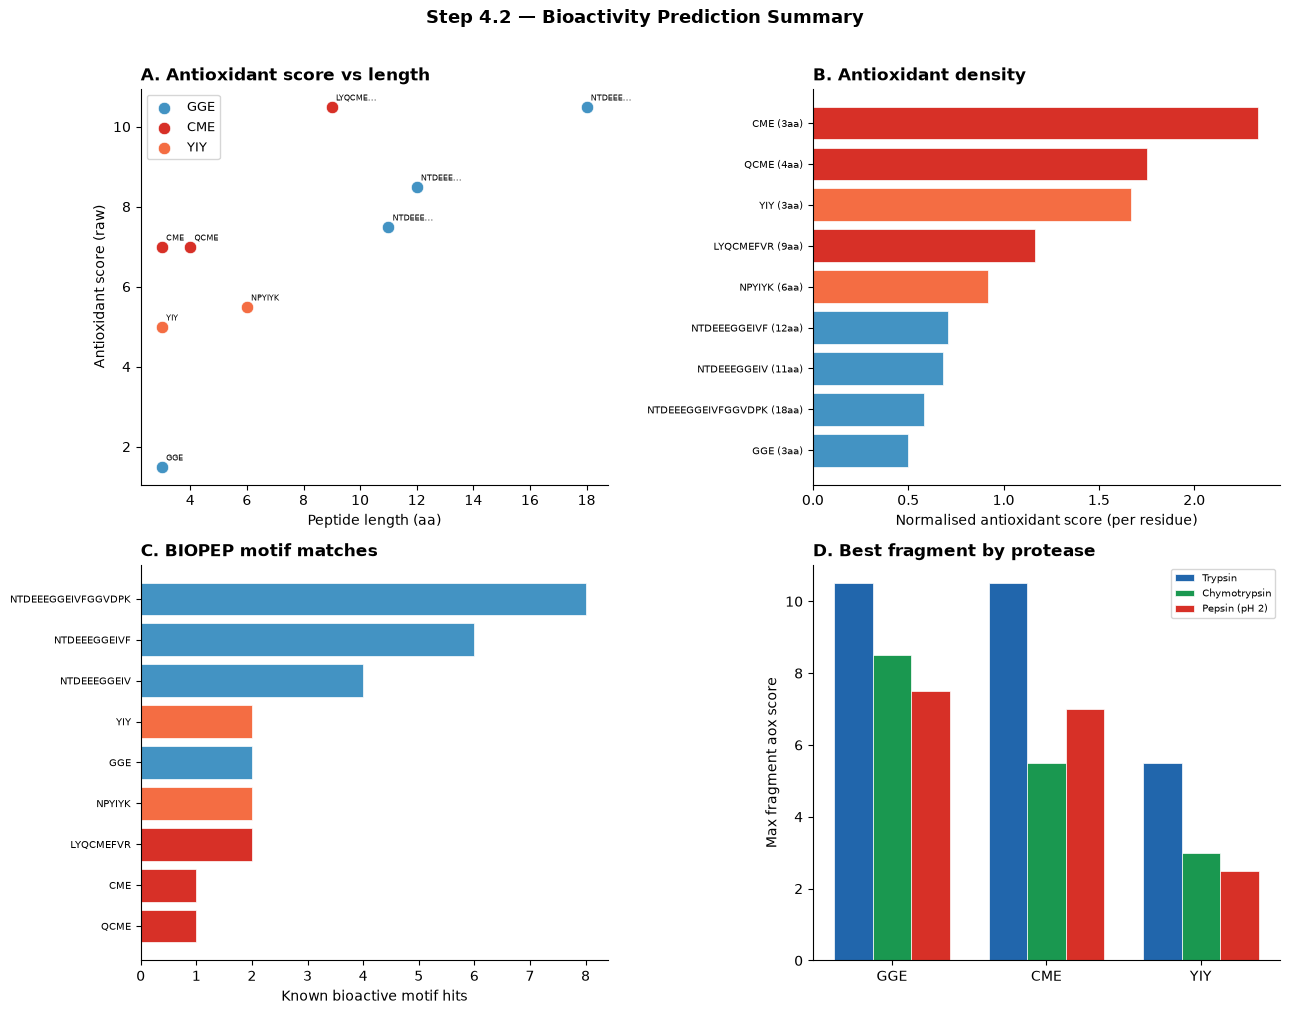

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Colour by parent motif
motif_colors = {'GGE': '#4393c3', 'CME': '#d73027', 'YIY': '#f46d43'}

# --- Panel A: Antioxidant raw score vs peptide length ---
ax = axes[0, 0]
for motif, color in motif_colors.items():
    subset = df_profiles[df_profiles['motif'] == motif]
    ax.scatter(subset['length'], subset['aox_raw_score'], 
              c=color, s=80, edgecolor='white', linewidth=0.5,
              label=motif, zorder=3)
    for _, row in subset.iterrows():
        ax.annotate(row['sequence'][:6] + ('...' if len(row['sequence']) > 6 else ''),
                   (row['length'], row['aox_raw_score']),
                   fontsize=6, ha='left', va='bottom',
                   xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('Peptide length (aa)')
ax.set_ylabel('Antioxidant score (raw)')
ax.set_title('A. Antioxidant score vs length', fontweight='bold', loc='left')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Panel B: Normalised antioxidant score (density) ---
ax = axes[0, 1]
# Sort by normalised score
df_sorted = df_profiles.sort_values('aox_normalised', ascending=True)
colors = [motif_colors[m] for m in df_sorted['motif']]
bars = ax.barh(range(len(df_sorted)), df_sorted['aox_normalised'],
               color=colors, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(df_sorted)))
ax.set_yticklabels([f"{s} ({n}aa)" for s, n in 
                     zip(df_sorted['sequence'], df_sorted['length'])], fontsize=7)
ax.set_xlabel('Normalised antioxidant score (per residue)')
ax.set_title('B. Antioxidant density', fontweight='bold', loc='left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Panel C: Bioactive motif counts per candidate ---
ax = axes[1, 0]
df_sorted_motifs = df_profiles.sort_values('n_bioactive_motifs', ascending=True)
colors_m = [motif_colors[m] for m in df_sorted_motifs['motif']]
ax.barh(range(len(df_sorted_motifs)), df_sorted_motifs['n_bioactive_motifs'],
        color=colors_m, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(df_sorted_motifs)))
ax.set_yticklabels([f"{s}" for s in df_sorted_motifs['sequence']], fontsize=7)
ax.set_xlabel('Known bioactive motif hits')
ax.set_title('C. BIOPEP motif matches', fontweight='bold', loc='left')
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Panel D: Protease-dependent yield (intact motif fragments) ---
ax = axes[1, 1]
# One grouped bar per peptide, bars per protease
pep_names = ['GGE', 'CME', 'YIY']
protease_names = ['Trypsin', 'Chymotrypsin', 'Pepsin (pH 2)']
protease_colors = ['#2166ac', '#1a9850', '#d73027']
x_pos = np.arange(len(pep_names))
width = 0.25

for j, (prot, color) in enumerate(zip(protease_names, protease_colors)):
    vals = []
    for pep in pep_names:
        row = agg[(agg['peptide'] == pep) & (agg['protease'] == prot)]
        vals.append(row['max_fragment_aox'].values[0] if len(row) > 0 else 0)
    ax.bar(x_pos + j * width, vals, width, label=prot,
           color=color, edgecolor='white', linewidth=0.5)

ax.set_xticks(x_pos + width)
ax.set_xticklabels(pep_names)
ax.set_ylabel('Max fragment aox score')
ax.set_title('D. Best fragment by protease', fontweight='bold', loc='left')
ax.legend(fontsize=7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('Step 4.2 — Bioactivity Prediction Summary',
             fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
fig_path = FIG_DIR / 'bioactivity_summary.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f"Saved: {fig_path}")
plt.show()

## 11. Export integrated bioactivity summary

In [11]:
# Phase 3 SASA context — add to profiles
PHASE3_DELTAS = {
    ('GGE', 'reline'):    +104.3, ('GGE', 'glyceline'):  +98.6,
    ('CME', 'reline'):    +187.1, ('CME', 'glyceline'): +243.6,
    ('YIY', 'reline'):    +119.8, ('YIY', 'glyceline'): +230.8,
}

df_summary = df_profiles.copy()
df_summary['SASA_increase_reline_pct'] = df_summary['motif'].map(
    lambda m: PHASE3_DELTAS.get((m, 'reline'), None))
df_summary['SASA_increase_glyceline_pct'] = df_summary['motif'].map(
    lambda m: PHASE3_DELTAS.get((m, 'glyceline'), None))

# Placeholder columns for web tool results
df_summary['peptideranker_score'] = None
df_summary['anticp_prediction'] = None
df_summary['biopep_activities'] = None

df_summary.to_csv(OUT_DIR / 'bioactivity_summary.csv', index=False)
print(f"Saved integrated summary → {OUT_DIR / 'bioactivity_summary.csv'}")
print(f"\nPlaceholder columns for web tool results:")
print(f"  peptideranker_score, anticp_prediction, biopep_activities")
print(f"  → Fill these after manual web submission")

Saved integrated summary → downstream/bioactivity/bioactivity_summary.csv

Placeholder columns for web tool results:
  peptideranker_score, anticp_prediction, biopep_activities
  → Fill these after manual web submission


## 12. Observations

### What this analysis shows

1. **CME has the highest antioxidant residue density** among the three bare
   tripeptide motifs. All three residues (C, M, E) contribute distinct antioxidant
   mechanisms: thiol radical scavenging, thioether reducing activity, and carboxyl
   metal chelation. This is consistent with the Durrani et al. finding that CME
   showed the highest experimental antioxidant activity.

2. **YIY derives its antioxidant potential from dual tyrosine phenolic groups.**
   The phenolic -OH groups donate hydrogen atoms to free radicals and the
   conjugated benzene ring stabilises radical intermediates. The isoleucine spacer
   may facilitate cooperative exposure of both tyrosine rings — consistent with
   the Durrani et al. SAR analysis.

3. **GGE relies primarily on carboxyl chelation** from its glutamic acid residue,
   with glycine providing backbone flexibility rather than direct radical
   scavenging. This explains its lower but still significant antioxidant activity
   relative to CME and YIY.

4. **Protease-dependent bioactive fragment yield varies:**
   - Trypsin preserves all motifs intact (expected — these are tryptic fragments)
   - Chymotrypsin disrupts CME and YIY, producing only partial-motif fragments
   - Pepsin preserves CME (in QCME, a 4-mer) but fragments YIY completely
   - GGE is preserved by all three proteases

5. **Longer fragments accumulate more bioactive motif hits** (ACE-inhibitory,
   DPP-IV inhibitory) alongside the core antioxidant motif. The 18-mer
   NTDEEEGGEIVFGGVDPK contains multiple overlapping bioactive sequences.

### Connection to DES enhancement

The Phase 3 SASA data shows all three motifs become substantially more
solvent-exposed in DES (+99 to +244%). Since Step 4.1 demonstrated that
cleavage sites within and adjacent to the motifs are within the construct
region, the DES-enhanced accessibility predicts more efficient protease
access to the parent protein regions that release these bioactive fragments.
This provides a computational rationale for the Durrani et al. observation
that DES extraction produced 63 antioxidant peptides vs 27 in water.

### Limitations

- The antioxidant scoring is heuristic, based on known residue-level
  mechanisms rather than a trained ML model; PeptideRanker results
  (when obtained) will provide an independent ML-based score
- Short peptides (2-3 aa) are at the lower size limit for most prediction
  tools; confidence is lower than for longer fragments
- The BIOPEP motif search uses a curated subset; a full database query
  may reveal additional bioactive subsequences
- Computational scores predict potential, not measured activity;
  the Durrani et al. in vitro assays remain the ground truth

### Next step

Top-ranked candidates (particularly CME-containing fragments and the full
tryptic peptides) proceed to Step 4.3 (Molecular Docking) against ACE,
Keap1-Nrf2, and COX-2 targets.